# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [Henry Fong]

**Date:** [09/02/2026]

In [ ]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
In the data table the price column has values that include comma 
such as 1,000 I used str.replace(',', '') to replace those comma
then astype(int) to convert those values into a integer ordered by
cheapest to most expensive
"""
path = "./data/airbnb_hw.csv"
df = pd.read_csv(path, low_memory=False)
df['price_clean'] = df['Price'].str.replace(',', '').astype(int)
df = df.sort_values(by="price_clean", ascending=True)
print(f"Missing values: {df['Price'].isnull().sum()}")
print(f"Cleaned Data: {df.head(5)}")

Missing values: 0
Cleaned Data:         Host Id  Host Since                                 Name  \
30087  41211757   8/11/2015         Private Room in Brooklyn, NY   
3120     751530   6/27/2011      Room in three-Bedroom Apartment   
19275  14381346   4/16/2014                           Small sofa   
9793    3991870  10/27/2012   1 Couch 8 min from Manhattan J\M\Z   
25139  25038105  12/20/2014  Cool Harlem Room available / shared   

      Neighbourhood  Property Type  Review Scores Rating (bin)  \
30087       Brooklyn     Apartment                         NaN   
3120        Brooklyn     Apartment                         NaN   
19275          Bronx         House                       100.0   
9793        Brooklyn     Apartment                        80.0   
25139      Manhattan         House                         NaN   

             Room Type  Zipcode  Beds  Number of Records  Number Of Reviews  \
30087     Private room  11219.0   1.0                  1                  0   
3120

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
A large proportion of the data was missing however I do not know
if it was a concern as when I cross-tabulate I did not find any patterns
"""

path = "./data/mn_police_use_of_force.csv"
df = pd.read_csv(path, low_memory=False)
cleaned_df = df.dropna()
print(f"Amount of null values in subject injury: {df['subject_injury'].isnull().sum()}")
print(f"Proportion of values missing: {round(df['subject_injury'].isnull().sum()/df['subject_injury'].count(), 2)}")
print(f"Cross-tabulation (cleaned data with non cleaned data): {pd.crosstab(cleaned_df['subject_injury'], df['force_type'])}")
print(f"Cross-tabulation (cleaned data with cleaned data): {pd.crosstab(cleaned_df['subject_injury'], cleaned_df['force_type'])}")

Amount of null values in subject injury: 9848
Proportion of values missing: 3.2
Cross-tabulation (cleaned data with non cleaned data): force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1080                119        2   
Yes                 2          1243                 40        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal Projectile  \
subject_injury                                                                 
No                             33                 34                       1   
Yes                            44                 40                       2   

force_type      Police K9 Bite  Taser  
subject_injury                         
No                           2    149  
Yes                         43    166  
Cross-tabulation (cleaned data with cleaned data): force_type      Baton  Bodily Force  Chemical Irritant  Firearm 

Shark attack by year: fYear
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: Year, Length: 87, dtype: int64


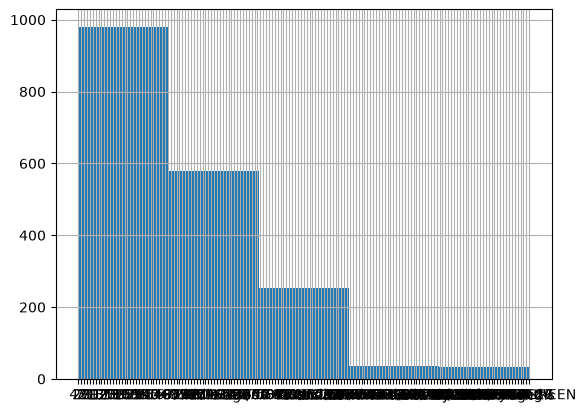

Proportion of male victim: Date              0.85
Year              0.85
Type              0.85
Country           0.85
State             0.81
Location          0.80
Activity          0.81
Name              0.85
Sex               0.85
Age               0.62
Injury            0.85
Fatal Y/N         0.80
Time              0.52
Species           0.54
Source            0.85
pdf               0.81
href formula      0.81
href              0.81
Case Number       0.81
Case Number.1     0.81
original order    0.81
Unnamed: 21       0.00
Unnamed: 22       0.00
dtype: float64
              Date    Year        Type           Country  \
0      26th August  2026.0  Unprovoked               USA   
1     23rd August   2026.0  Unprovoked               USA   
2      19th August  2026.0    Provoked    Reunion Island   
3      11th August  2026.0    Provoked           Ireland   
4       8th August  2026.0  Unprovoked               USA   
...            ...     ...         ...               ...   
5574   15

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

"""
From since 1940 the attacks have been increasing the proportion of victims that are male are .85
and the proportion of unprovoked attacks is .89
"""

path = "./data/GSAF5.xls"
df = pd.read_excel(path)
cleaned_df = df.dropna(how='all', axis=1)
cleaned_df = cleaned_df.query("Year >= 1940")
print(f"Shark attack by year: f{cleaned_df.astype('str').groupby('Year')['Year'].count()}")
cleaned_age_df = cleaned_df['Age'].replace('?', np.nan).dropna()
cleaned_age_df = cleaned_age_df.str.replace("'s", '').replace('+','')
chart = cleaned_age_df.hist(bins=5)
plt.show(chart)
print(f"Proportion of male victim: {round(cleaned_df.query("Sex == 'M'").count()/cleaned_df['Sex'].count(),2)}")
cleaned_type_df = cleaned_df.query("Type == 'Unprovoked' or Type == 'Provoked' or Type == 'Unknown'")
print(f"Proportion of unprovoked attacks: {round(cleaned_type_df.query("Type == 'Unprovoked'").count()/cleaned_type_df.count(),2)}")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [4bffc62]
- **AI tool and model used:** [Google Gemini]

### *Prompts used

1. [Here is my code I want you to tell me what I could do to improve it]
2. [I also had an issue with creating the histogram where it was too much data bunched together and I don't think I did the proportation correctly could you help me with that]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Aggressive Dropna (df.dropna()): Dropping all rows with any null value in the first dataset likely wipes out most of your rows, invalidating your cross-tabulation comparison. Drop missing values per column instead.

Denominators in Proportions:

df['subject_injury'].count() counts non-null values. Dividing nulls by non-nulls gives an incorrect ratio. Use len(df) or df['subject_injury'].shape[0].

cleaned_df.query("Sex == 'M'").count() returns a Series instead of a scalar, leading to an incorrect proportion output.

Nested Quote Syntax Errors: Python throws a SyntaxError when double quotes are nested inside double-quoted f-strings (e.g., f" ... query("Sex == 'M'") ... ").

String Conversion Overhead: cleaned_df.astype('str') converts the entire DataFrame to strings just to count records per year. Use .value_counts() or .groupby('Year').size().

String Cleaning Bug: .replace('+', '') on a string Series looks for exact string matches rather than stripping character patterns. Use .str.replace('+', '', regex=False).
2. String Data Type (object): The Age column remained formatted as text strings rather than numbers. When Matplotlib plots a histogram of string data, it treats every unique text variation (e.g., "20", "20s", "20 ") as a distinct categorical label along the x-axis rather than continuous numbers.

Incomplete Regex Cleaning: Calls like .replace('+', '') without regex=True only match exact strings. Values like "45+" or "18 or 20" remained messy strings.

Undefined Numeric Bins: Setting bins=5 on unparsed strings forces Matplotlib to guess how to divide non-numeric labels, resulting in squeezed, overlapping bars.

Why the Proportions Were Incorrect

DataFrame .count() vs. Scalar Numbers: Running .count() on a DataFrame returns a pandas.Series containing row counts for every individual column, rather than a single number. Dividing two DataFrames or a DataFrame by a single integer yields a Series of proportions for every column.

Trailing Whitespace and Formatting: Values in datasets like GSAF frequently contain trailing spaces (e.g., 'M ' or 'Unprovoked '). Using Sex == 'M' ignores 'M ', artificially deflating your count.

Denominator Mismatches: In df.query(...).count() / df.count(), if missing values exist in unrelated columns, the non-null count varies across columns, distorting the calculation.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | The cross-tabulation was something that I want not able to find a correlation and using the .count() in my code made it return a large amount of values that was not necessary |
| 2 | **Accept** / modify / reject | The solution that ai provided helped to make it much clear and easier to read the chart and see the proportion|

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# Dataset 1: MN Police Use of Force
# ==========================================
path_police = "./data/mn_police_use_of_force.csv"
df_police = pd.read_csv(path_police, low_memory=False)

# 1. Missing value metrics
null_count = df_police['subject_injury'].isnull().sum()
total_rows = len(df_police)
missing_prop = null_count / total_rows

print(f"Amount of null values in subject injury: {null_count}")
print(f"Proportion of values missing: {missing_prop:.2%}")

# 2. Cross-tabulation: compare full data vs dropping nulls in relevant columns only
cleaned_police = df_police.dropna(subset=['subject_injury', 'force_type'])

print("\nCross-tabulation (Uncleaned):")
print(pd.crosstab(df_police['subject_injury'], df_police['force_type'], dropna=False))

print("\nCross-tabulation (Cleaned):")
print(pd.crosstab(cleaned_police['subject_injury'], cleaned_police['force_type']))


Amount of null values in subject injury: 9848
Proportion of values missing: 76.19%

Cross-tabulation (Uncleaned):
force_type      Baton  Bodily Force  Chemical Irritant  Firearm  \
subject_injury                                                    
No                  0          1093                131        2   
Yes                 2          1286                 41        0   
NaN                 2          7051               1421        0   

force_type      Gun Point Display  Improvised Weapon  Less Lethal  \
subject_injury                                                      
No                             33                 34            0   
Yes                            44                 40            0   
NaN                            27                 74           87   

force_type      Less Lethal Projectile  Maximal Restraint Technique  \
subject_injury                                                        
No                                   1                        


Shark attacks by year:
Year
1940.0     24
1941.0     27
1942.0     41
1943.0     28
1944.0     31
         ... 
2022.0     98
2023.0    109
2024.0     52
2025.0     69
2026.0     53
Name: count, Length: 87, dtype: int64


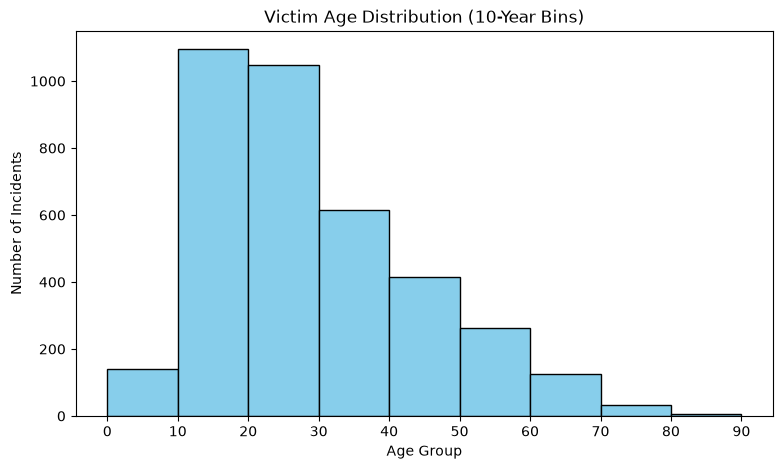

Male Victim Proportion: 85.72%
Unprovoked Attack Proportion: 88.74%
Proportion of unprovoked attacks: 88.78%


In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==========================================
# Dataset 2: Global Shark Attack File
# ==========================================
path_gsaf = "./data/GSAF5.xls"
df_shark = pd.read_excel(path_gsaf)

# Clean empty columns & filter years
cleaned_shark = df_shark.dropna(how='all', axis=1).copy()
cleaned_shark = cleaned_shark.query("Year >= 1940")

# 1. Shark attacks by year
print("\nShark attacks by year:")
print(cleaned_shark['Year'].value_counts().sort_index())

# 2. Clean 'Age' column properly
cleaned_age = (
    cleaned_shark['Age']
    .replace('?', np.nan)
    .dropna()
    .astype(str)
    .str.replace("'s", "", regex=False)
    .str.replace("+", "", regex=False)
)
# FIX: Extract digits using Regex, convert to numeric, and set explicit bins
# 1. Extract the first sequence of digits (e.g., '20s' -> 20, '45+' -> 45)
age_numeric = pd.to_numeric(
    cleaned_df['Age'].astype(str).str.extract(r'(\d+)', expand=False), 
    errors='coerce'
).dropna()

# 2. Filter reasonable age limits (0 to 100)
age_numeric = age_numeric[age_numeric.between(0, 100)]

# 3. Plot using explicit 10-year bin intervals
plt.figure(figsize=(9, 5))
plt.hist(age_numeric, bins=range(0, 100, 10), edgecolor='black', color='skyblue')
plt.xticks(range(0, 100, 10))
plt.title("Victim Age Distribution (10-Year Bins)")
plt.xlabel("Age Group")
plt.ylabel("Number of Incidents")
plt.show()

# FIX: Clean strings and use scalar counts (.sum() or len())

# 1. Male Victim Proportion
# Clean whitespace and normalize text
sex_series = cleaned_df['Sex'].astype(str).str.strip().str.upper()

males = (sex_series == 'M').sum()
known_genders = sex_series.isin(['M', 'F']).sum()

prop_male = males / known_genders
print(f"Male Victim Proportion: {prop_male:.2%}")

# 2. Unprovoked Attack Proportion
type_series = cleaned_df['Type'].astype(str).str.strip().str.title()

# Filter to valid categories
valid_types = type_series[type_series.isin(['Unprovoked', 'Provoked', 'Unknown'])]

unprovoked_count = (valid_types == 'Unprovoked').sum()
total_valid = len(valid_types)

prop_unprovoked = unprovoked_count / total_valid
print(f"Unprovoked Attack Proportion: {prop_unprovoked:.2%}")

# 4. Proportion of unprovoked attacks
valid_types = ['Unprovoked', 'Provoked', 'Unknown']
cleaned_type_df = cleaned_shark[cleaned_shark['Type'].isin(valid_types)]

unprovoked_count = (cleaned_type_df['Type'] == 'Unprovoked').sum()
total_valid_types = len(cleaned_type_df)
print(f"Proportion of unprovoked attacks: {unprovoked_count / total_valid_types:.2%}")


### *Reflection on AI assistance
In your own words without generative AI.

The main improvement that AI made was making changes to the graph or my code where I was not getting the correct solution such as the cross tabulation where I was dropping too much data which caused me to get incorrect data. The limitation with AI is it is based on what you want to make for example AI can make a graph or help make you a cross tabulation table or help you remove only data that you should remove and not everything it still requires you to tell it what to do and what you want it to do if you don’t give it goals or what you want to do it isn’t able to help much as it doesn’t know what you are trying to accomplish. The final solution was verified by looking at what was produced and then looking at what I made and testing to see if there were any major differences or if there was a data point that was incorrect. 